# Day 1 - Beginner track
## Python, pandas and the messy truth about real data

**MIPT International Autumn School 2026 | 8 September | 90 minutes**

By the end of this session you will have taken a raw, deliberately broken dataset of
4,255 used-car listings and turned it into something a model can actually learn from.

### How this notebook works

* Run every cell in order with `Shift + Enter`.
* Cells marked **YOUR TURN** contain a `# TODO`. That is the part you write.
* Every section ends with a **Checkpoint** telling you what you should be seeing.
  If your output does not match, raise your hand before moving on.
* There is no internet in this room. Everything you need is already on disk.

### The dataset

`car_listings.csv` is a snapshot of used-car adverts. Each row is one listing.
It has two targets, and we will use both over the next four days:

| Target | Type of task | Question it answers |
|---|---|---|
| `price_eur` | regression | what should this car cost? |
| `sold_fast` | classification | will this listing sell within 30 days? |

In [ ]:
# Section 0 - environment check. Run this first.
import sys
print("Python:", sys.version.split()[0])

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)

# Plots appear inside the notebook rather than in a separate window
%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("\nEnvironment OK. If any import failed, tell the instructor now.")

Python: 3.13.15
numpy: 2.1.3
pandas: 2.2.3
matplotlib: 3.10.0

Environment OK. If any import failed, tell the instructor now.


---
# Part 1 - A ten minute Python refresher

Skip ahead if this is all familiar. If it is not, these four cells cover
essentially every Python construct used in the rest of the school.

In [ ]:
# Lists, dicts, and the two loops you will actually write

brands = ["Toyota", "BMW", "Kia"]
prices = {"Toyota": 9500, "BMW": 14200, "Kia": 7800}

for b in brands:
    print(f"{b:12s} costs about {prices[b]:,} EUR")

# List comprehension: build a new list from an old one in one line
expensive = [b for b in brands if prices[b] > 9000]
print("\nAbove 9000 EUR:", expensive)

# Dict comprehension: same idea, applying a 10 percent discount
discounted = {b: round(p * 0.9) for b, p in prices.items()}
print("After a 10 percent cut:", discounted)

Toyota       costs about 9,500 EUR
BMW          costs about 14,200 EUR
Kia          costs about 7,800 EUR

Above 9000 EUR: ['Toyota', 'BMW']
After a 10 percent cut: {'Toyota': 8550, 'BMW': 12780, 'Kia': 7020}


In [ ]:
# Functions, and why default arguments matter

def depreciate(price, years, rate=0.12):
    """Value of a car after `years` of losing `rate` of its value annually."""
    return price * (1 - rate) ** years

print("A 20000 EUR car after 5 years:", round(depreciate(20000, 5)))
print("...if it holds value better:  ", round(depreciate(20000, 5, rate=0.07)))

# Functions are ordinary objects: you can pass them around
def apply_to_all(values, fn):
    return [fn(v) for v in values]

print("\nSquares:", apply_to_all([1, 2, 3, 4], lambda x: x ** 2))

A 20000 EUR car after 5 years: 10555
...if it holds value better:   13914

Squares: [1, 4, 9, 16]


In [ ]:
# NumPy in ninety seconds: arrays are lists that do maths

a = np.array([1.0, 2.0, 3.0, 4.0])

print("a          ", a)
print("a * 2      ", a * 2)          # every element, no loop
print("a + a      ", a + a)
print("a.mean()   ", a.mean())
print("a.std()    ", round(a.std(), 3))

# Boolean masks are how you filter data. Remember this pattern, you will use
# it constantly.
mask = a > 2.
print("\nmask       ", mask)
print("a[mask]    ", a[mask])

# 2D arrays: shape is (rows, columns)
m = np.arange(12).reshape(3, 4)
print("\nm:\n", m)
print("shape:", m.shape, "| column means:", m.mean(axis=0))

a           [1. 2. 3. 4.]
a * 2       [2. 4. 6. 8.]
a + a       [2. 4. 6. 8.]
a.mean()    2.5
a.std()     1.118

mask        [False False  True  True]
a[mask]     [3. 4.]

m:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
shape: (3, 4) | column means: [4. 5. 6. 7.]


### YOUR TURN 1

Write a function `annual_km(mileage, year, current_year=2026)` that returns the
average kilometres driven per year. Guard against division by zero for a car
registered this year: in that case just return the mileage itself.

In [ ]:
# TODO: write the function
def annual_km(mileage, year, current_year=2026):
    age = current_year - year
    if age <= 0:
        return float(mileage)
    return mileage / age


# These should print 15000.0, 8000.0 and 3200.0
print(annual_km(150000, 2016))
print(annual_km(80000, 2016))
print(annual_km(3200, 2026))

15000.0
8000.0
3200.0


---
# Part 2 - First contact with the data

The single most important habit in this whole field: **look at your data before
you model it.** Every hour spent here saves three later.

In [ ]:
DATA_PATH = "/content/sample_data/car_listings.csv"   # ask the instructor if this path fails

df = pd.read_csv(DATA_PATH)

print("Rows and columns:", df.shape)
df.head(10)

Rows and columns: (4255, 15)


,listing_id,brand,model_year,mileage_km,engine_litres,fuel_type,transmission,body_type,owners,service_history,accident_reported,city,days_on_market,price_eur,sold_fast
0,L100394,Renault,2011,321312.0,1.9,petrol,manual,sedan,4.0,partial,0,Kazan,62,2400.0,0
1,L100940,Kia,2015,116734.0,1.7,petrol,automatic,hatchback,3.0,NaN,1,Novosibirsk,42,5070.0,0
2,L103383,Ford,2015,157618.0,0.9,petrol,automatic,suv,3.0,NaN,1,Yekaterinburg,9,4580.0,1
3,L100930,Kia,2017,60355.0,2.0,petrol,manual,hatchback,3.0,none,0,Novosibirsk,52,6570.0,0
4,L103083,Volkswagen,2020,81292.0,2.1,hybrid,automatic,suv,3.0,full,0,Yekaterinburg,100,17460.0,0
5,L100757,Toyota,2016,160748.0,1.4,diesel,manual,sedan,2.0,partial,0,Moscow,8,7490.0,1
6,L100556,Ford,2021,60094.0,2.3,petrol,manual,sedan,NaN,partial,0,Yekaterinburg,70,14020.0,0
7,L103140,BMW,2009,321363.0,1.6,hybrid,manual,NaN,2.0,partial,0,Moscow,10,3710.0,1
8,L100354,Toyota,2012,118005.0,1.4,petrol,automatic,sedan,1.0,full,1,Moscow,8,5320.0,1
9,L100357,Skoda,2015,133137.0,1.6,diesel,automatic,NaN,1.0,full,0,Novosibirsk,3,5950.0,1


In [ ]:
# .info() tells you the dtype and the non-null count of every column.
# Read the non-null counts carefully: they are your first missing-value report.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4255 entries, 0 to 4254
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   listing_id         4255 non-null   object 
 1   brand              4255 non-null   object 
 2   model_year         4255 non-null   int64  
 3   mileage_km         4073 non-null   float64
 4   engine_litres      4038 non-null   float64
 5   fuel_type          4255 non-null   object 
 6   transmission       4255 non-null   object 
 7   body_type          4175 non-null   object 
 8   owners             4143 non-null   float64
 9   service_history    3953 non-null   object 
 10  accident_reported  4255 non-null   int64  
 11  city               4255 non-null   object 
 12  days_on_market     4255 non-null   int64  
 13  price_eur          4255 non-null   float64
 14  sold_fast          4255 non-null   int64  
dtypes: float64(4), int64(4), object(7)
memory usage: 498.8+ KB


In [ ]:
# .describe() summarises the numeric columns.
# Look for values that cannot physically exist.
df.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
model_year,4255.0,2016.0,8.0,1900.0,2014.0,2016.0,2019.0,2025.0
mileage_km,4073.0,147249.9,197572.4,-1.0,68566.0,114136.0,179519.0,4012300.0
engine_litres,4038.0,1.8,0.5,0.9,1.5,1.8,2.1,3.8
owners,4143.0,2.1,1.0,1.0,1.0,2.0,3.0,5.0
accident_reported,4255.0,0.2,0.4,0.0,0.0,0.0,0.0,1.0
days_on_market,4255.0,43.4,42.1,1.0,7.0,35.0,72.0,251.0
price_eur,4255.0,10099.0,7163.8,900.0,5105.0,8090.0,12930.0,61500.0
sold_fast,4255.0,0.5,0.5,0.0,0.0,0.0,1.0,1.0


### YOUR TURN 2

Look hard at the two outputs above and answer these in the cell below.
Write your answers as comments, then compute each one.

1. How many listings are in the dataset?
2. Which column has the most missing values, and how many?
3. What is the minimum value of `mileage_km`, and is it physically possible?
4. What is the earliest `model_year`, and is it plausible for a used-car advert?

In [ ]:
# TODO: compute each answer

# 1. number of listings
print("rows:", len(df))

# 2. missing values per column, largest first
print(df.isna().sum().sort_values(ascending=False).head())


# 3. minimum mileage
print("min mileage:", df["mileage_km"].min())

# 4. earliest model year
print("earliest year:", df['model_year'].min())

rows: 4255
service_history    302
engine_litres      217
mileage_km         182
owners             112
body_type           80
dtype: int64
min mileage: -1.0
earliest year: 1900


**Checkpoint.** You should have found: 4255 rows, `service_history` missing about
300 values, a minimum mileage of `-1`, and a minimum model year of `1900`.

Those last two are not outliers. They are **sentinel values**: someone's software
wrote a placeholder into a numeric field. If you leave them in, your model will
believe some cars have travelled minus one kilometre.

---
# Part 3 - The data quality audit

Four things are wrong with almost every real dataset:

1. **Inconsistent categories** - the same value spelled several ways
2. **Duplicates** - the same record entered twice
3. **Impossible values** - sentinels and typos
4. **Missing values** - and they are rarely missing at random

We will fix them in that order, because fixing categories first makes the rest easier.

In [ ]:
# Problem 1: inconsistent categories.
# Always list the unique values of every text column before you trust it.

for col in ["brand", "fuel_type", "transmission", "body_type", "city", "service_history"]:
    print(f"{col:18s} -> {sorted(df[col].dropna().unique().tolist())}")
    print()

brand              -> [' BMW ', ' Ford ', ' Hyundai ', ' Kia ', ' Renault ', ' Skoda ', ' Toyota ', ' Volkswagen ', 'BMW', 'Ford', 'Hyundai', 'Kia', 'Renault', 'Skoda', 'Toyota', 'Volkswagen']

fuel_type          -> ['DIESEL', 'ELECTRIC', 'HYBRID', 'PETROL', 'diesel', 'electric', 'hybrid', 'petrol']

transmission       -> ['automatic', 'manual']

body_type          -> ['hatchback', 'sedan', 'suv', 'wagon']

city               -> ['Kazan', 'Moscow', 'Novosibirsk', 'Sochi', 'Yekaterinburg', 'kazan', 'moscow', 'novosibirsk', 'sochi', 'yekaterinburg']

service_history    -> ['full', 'none', 'partial']



Notice `'PETROL'` next to `'petrol'`, `'moscow'` next to `'Moscow'`, and brands
padded with spaces like `' Toyota '`. To a computer these are entirely different
categories. Left alone, `Toyota` would be split into two separate one-hot columns
and the model would learn each half from half the data.

### YOUR TURN 3

Normalise the text columns: strip surrounding whitespace, and lowercase
`fuel_type` and `city`. Confirm that `brand` drops back to 8 unique values.

In [ ]:
clean = df.copy()

# TODO: strip whitespace from every text column, then lowercase fuel_type and city
# Hint: clean[col].str.strip() and clean[col].str.lower()


text_cols = ["brand", "fuel_type", "transmission", "body_type", "city", "service_history"]
for col in text_cols:
    clean[col] = clean[col].str.strip()

clean["fuel_type"] = clean["fuel_type"].str.lower()
clean["city"] = clean["city"].str.lower()


print("brand      :", clean["brand"].nunique(), "unique")
print("fuel_type  :", sorted(clean["fuel_type"].dropna().unique().tolist()))
print("city       :", sorted(clean["city"].dropna().unique().tolist()))

brand      : 8 unique
fuel_type  : ['diesel', 'electric', 'hybrid', 'petrol']
city       : ['kazan', 'moscow', 'novosibirsk', 'sochi', 'yekaterinburg']


In [ ]:
# Problem 2: duplicates.
# listing_id is unique by construction, so we must ignore it when looking for
# genuine duplicate records.

feature_cols = [c for c in clean.columns if c != "listing_id"]
n_dupes = clean.duplicated(subset=feature_cols).sum()
print("Exact duplicate listings:", n_dupes)

clean = clean.drop_duplicates(subset=feature_cols).reset_index(drop=True)
print("Rows after removing them:", len(clean))

Exact duplicate listings: 55
Rows after removing them: 4200


In [ ]:
# Problem 3: impossible values.
# The honest fix is to convert them to NaN, which says "we do not know",
# rather than to invent a number.

print("Before:")
print("  mileage below zero :", (clean["mileage_km"] < 0).sum())
print("  model_year < 1990  :", (clean["model_year"] < 1990).sum())

clean.loc[clean["mileage_km"] < 0, "mileage_km"] = np.nan
clean.loc[clean["model_year"] < 1990, "model_year"] = np.nan

print("\nAfter, these become part of the missing-value problem:")
print(clean[["mileage_km", "model_year"]].isna().sum())

Before:
  mileage below zero : 26
  model_year < 1990  : 14

After, these become part of the missing-value problem:
mileage_km    205
model_year     14
dtype: int64


---
# Part 4 - Missing values

There is no universally correct fix. There is only a defensible choice, and the
duty to write down which one you made.

| Strategy | When it is reasonable | The risk |
|---|---|---|
| Drop the rows | very few rows affected, missing at random | you throw away data, and bias it if not random |
| Drop the column | most of the column is missing | you lose a possibly useful signal |
| Fill with mean | roughly symmetric numeric column | shrinks the variance, distorts the distribution |
| Fill with median | skewed numeric column, has outliers | same, but far more robust |
| Fill with a new category | text column where "unknown" is meaningful | adds a category the model must learn |
| Add a "was missing" flag | when missingness itself carries signal | one extra column each time |

For `service_history`, a missing value very likely means the seller had nothing
good to report. That is information. We keep it as its own category rather than
pretending it was `full`.

In [ ]:
# Numeric columns: median, because these distributions are skewed.
for col in ["mileage_km", "engine_litres", "owners", "model_year"]:
    fill = clean[col].median()
    n = clean[col].isna().sum()
    clean[col] = clean[col].fillna(fill)
    print(f"{col:15s} filled {n:4d} values with median {fill}")

# Text columns: an explicit "unknown" category.
for col in ["service_history", "body_type"]:
    n = clean[col].isna().sum()
    clean[col] = clean[col].fillna("unknown")
    print(f"{col:15s} filled {n:4d} values with 'unknown'")

print("\nRemaining missing values:", clean.isna().sum().sum())

mileage_km      filled  205 values with median 115055.0
engine_litres   filled  214 values with median 1.8
owners          filled  109 values with median 2.0
model_year      filled   14 values with median 2016.0
service_history filled  298 values with 'unknown'
body_type       filled   79 values with 'unknown'

Remaining missing values: 0


> **A trap worth naming now.** We filled with the median of the *whole* dataset.
> That includes rows that will later become our test set, so a little information
> has leaked from test into train. It is a small leak here, and on Day 2 you will
> learn the correct pattern: fit the imputer on the training data only.
> Remember that this cell is technically cheating.

---
# Part 5 - Outliers

An outlier is not automatically an error. A genuine 400,000 km taxi belongs in the
data. A car with 4,012,300 km does not.

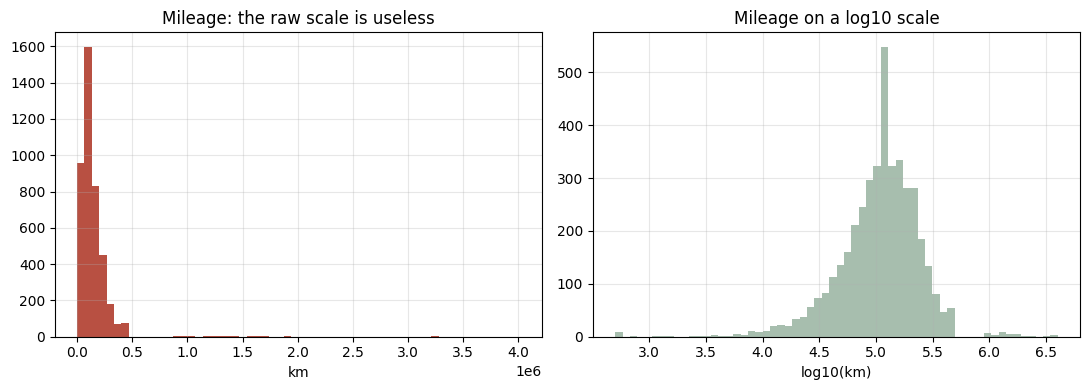

count       4200.0
mean      146633.0
std       193741.0
min          500.0
25%        71221.0
50%       115055.0
75%       176136.0
max      4012300.0
Name: mileage_km, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(clean["mileage_km"], bins=60, color="#B85042")
axes[0].set_title("Mileage: the raw scale is useless")
axes[0].set_xlabel("km")

axes[1].hist(np.log10(clean["mileage_km"].clip(lower=1)), bins=60, color="#A7BEAE")
axes[1].set_title("Mileage on a log10 scale")
axes[1].set_xlabel("log10(km)")
plt.tight_layout()
plt.show()

print(clean["mileage_km"].describe().round(0))

The left plot is a single spike with an invisible tail: a handful of extreme values
have stretched the axis until the other 4,000 listings are one bar. The log plot
shows what is really there, and reveals a small clump far to the right.

Those are unit-entry errors: a mileage typed with an extra zero.

### YOUR TURN 4

Count how many listings have `mileage_km` above 500,000. Then decide what to do
with them and implement it. Any of these is defensible as long as you can justify it:

* drop those rows
* clip them to a sane maximum
* divide by 10, assuming an extra zero was typed

Look at the log plot above before you choose the cutoff. There is a visible gap
between the genuine right tail and the corrupted values.

Write one sentence of justification as a comment.

In [ ]:
# TODO: count the extreme values
n_extreme = ...
print("listings above 500,000 km:", n_extreme)

# TODO: your justification, in one sentence


# TODO: implement your fix on `clean`


print("new max mileage:", clean["mileage_km"].max())

listings above 500,000 km: Ellipsis
new max mileage: 4012300.0


---
# Part 6 - Looking at the data properly

Four plots that you should draw for essentially every tabular dataset you meet.

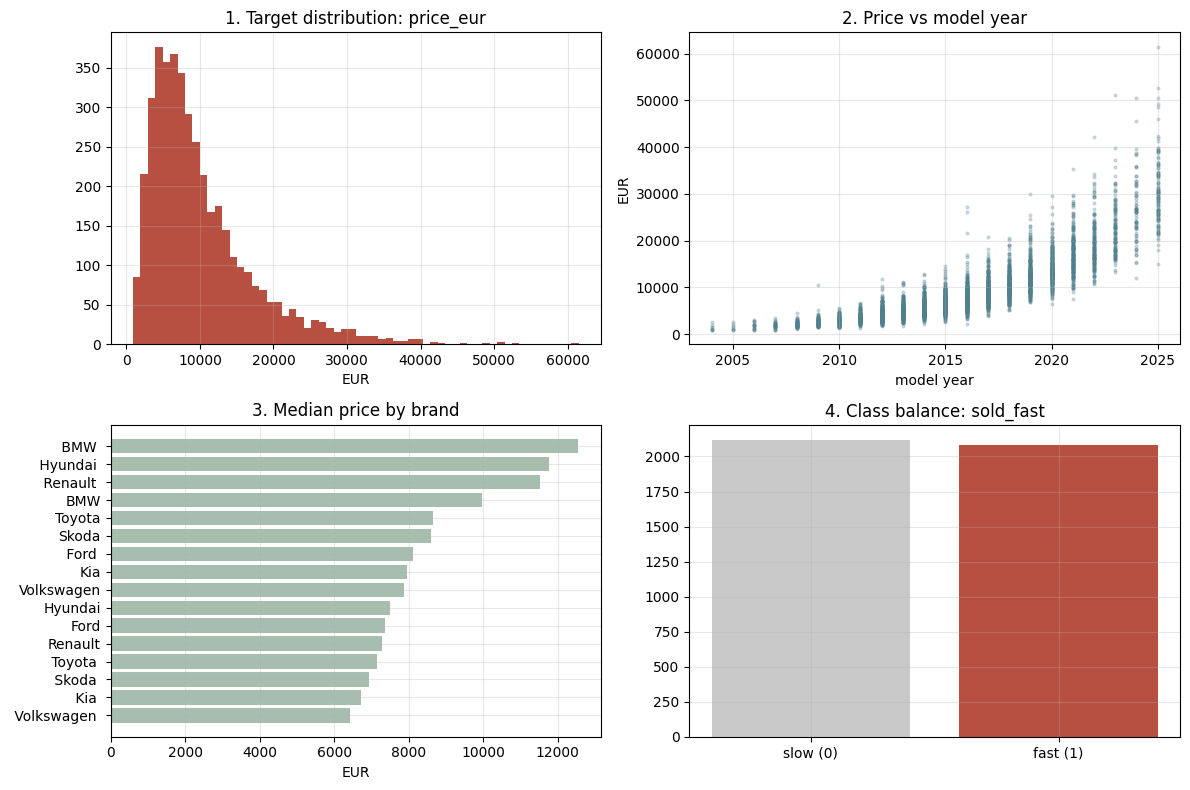

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. The distribution of the target
axes[0, 0].hist(clean["price_eur"], bins=60, color="#B85042")
axes[0, 0].set_title("1. Target distribution: price_eur")
axes[0, 0].set_xlabel("EUR")

# 2. The target against the strongest numeric feature
axes[0, 1].scatter(clean["model_year"], clean["price_eur"], s=4, alpha=0.25, color="#50808E")
axes[0, 1].set_title("2. Price vs model year")
axes[0, 1].set_xlabel("model year")
axes[0, 1].set_ylabel("EUR")

# 3. The target broken down by a category
order = clean.groupby("brand")["price_eur"].median().sort_values()
axes[1, 0].barh(order.index, order.values, color="#A7BEAE")
axes[1, 0].set_title("3. Median price by brand")
axes[1, 0].set_xlabel("EUR")

# 4. Class balance of the classification target
counts = clean["sold_fast"].value_counts().sort_index()
axes[1, 1].bar(["slow (0)", "fast (1)"], counts.values, color=["#C9C9C9", "#B85042"])
axes[1, 1].set_title("4. Class balance: sold_fast")

plt.tight_layout()
plt.show()

Read plot 1 again. The price distribution has a long right tail: most cars are
cheap, a few are very expensive. This shape appears constantly in prices, incomes
and populations, and it matters enormously.

Try the log of the target and watch what happens.

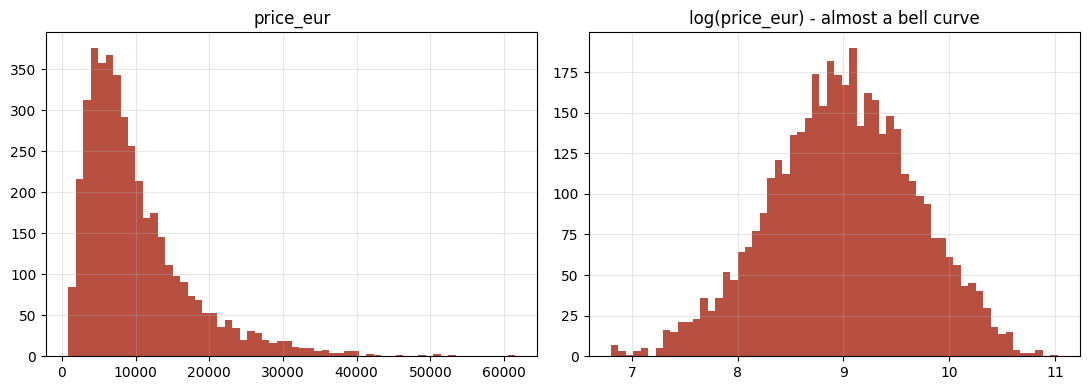

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(clean["price_eur"], bins=60, color="#B85042")
axes[0].set_title("price_eur")
axes[1].hist(np.log(clean["price_eur"]), bins=60, color="#B85042")
axes[1].set_title("log(price_eur) - almost a bell curve")
plt.tight_layout()
plt.show()

Hold on to this. On Day 2 you will fit a model on `price_eur` and get an R squared
around 0.80, then fit exactly the same model on `log(price_eur)` and get about 0.95.
No new algorithm, no tuning. Just the right target.

### YOUR TURN 5

Produce one plot of your own that answers a question you actually have about this
data, and write the finding as a comment. Some starting points:

* does an accident report reduce price, and by how much?
* how much cheaper is a car with no service history?
* is mileage or age the stronger predictor of price?
* which city has the fastest-selling listings?

In [ ]:
# TODO: one plot, one question, one finding written as a comment

---
# Part 7 - Preparing features for a model

Models take numbers. Our dataset is half text. Two conversions cover almost
everything you will meet.

**One-hot encoding** turns a category with no natural order into one column per
value. `fuel_type` becomes `fuel_petrol`, `fuel_diesel`, `fuel_hybrid`,
`fuel_electric`, each holding 0 or 1.

**Ordinal encoding** turns an ordered category into a single number.
`service_history` genuinely runs none < partial < full, so one column is enough
and it carries the ordering.

Getting this backwards is a classic beginner error. If you ordinal-encode `city`
as Moscow=0, Kazan=1, Sochi=2, you have told the model that Kazan sits exactly
halfway between Moscow and Sochi, which is meaningless.

In [ ]:
# Ordinal, because the order is real
service_order = {"none": 0, "unknown": 1, "partial": 2, "full": 3}
clean["service_level"] = clean["service_history"].map(service_order)

# A derived feature: age is easier for a model to use than a raw year
clean["age_years"] = 2026 - clean["model_year"]

# One-hot for the unordered categories
model_df = pd.get_dummies(
    clean[["brand", "fuel_type", "transmission", "body_type", "city"]],
    drop_first=True,
).astype(int)

# Assemble the final feature matrix
numeric = clean[["age_years", "mileage_km", "engine_litres", "owners",
                 "accident_reported", "service_level"]]
X = pd.concat([numeric.reset_index(drop=True), model_df.reset_index(drop=True)], axis=1)

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (4200, 42)


,age_years,mileage_km,engine_litres,owners,accident_reported,service_level,brand_ Ford,brand_ Hyundai,brand_ Kia,brand_ Renault,...,body_type_wagon,city_Moscow,city_Novosibirsk,city_Sochi,city_Yekaterinburg,city_kazan,city_moscow,city_novosibirsk,city_sochi,city_yekaterinburg
0,15.0,321312.0,1.9,4.0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,11.0,116734.0,1.7,3.0,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,11.0,157618.0,0.9,3.0,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,9.0,60355.0,2.0,3.0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,6.0,81292.0,2.1,3.0,0,3,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


Why `drop_first=True`? With four fuel types you only need three columns: if all
three are 0, the car must be the fourth type. Keeping all four makes the columns
perfectly predictable from each other, which breaks linear models.

---
# Part 8 - Checkpoint: save your work

Tomorrow's session starts from this file. Save it now.

In [ ]:
y_price = clean["price_eur"]
y_sold = clean["sold_fast"]

out = X.copy()
out["price_eur"] = y_price.values
out["sold_fast"] = y_sold.values
out.to_csv("day1_beginner_clean.csv", index=False)

print("Saved day1_beginner_clean.csv")
print("  shape        :", out.shape)
print("  missing values:", out.isna().sum().sum())
print("  price range  :", int(y_price.min()), "to", int(y_price.max()), "EUR")
print("  sold_fast    :", f"{y_sold.mean():.1%} of listings sold within 30 days")

Saved day1_beginner_clean.csv
  shape        : (4200, 44)
  missing values: 0
  price range  : 900 to 61500 EUR
  sold_fast    : 49.5% of listings sold within 30 days


### What you should be able to state before you leave

1. Why `-1` in a mileage column is more dangerous than a genuine outlier.
2. Why `' Toyota '` and `'Toyota'` cost you accuracy.
3. Why we filled `service_history` with `'unknown'` instead of `'full'`.
4. Why `city` gets one-hot encoding but `service_history` does not.
5. What the log of the price distribution looked like, and why that will matter tomorrow.

---
### Stretch tasks for the afternoon self-study block

**A.** We dropped `days_on_market` from the feature matrix without comment. Add it
back, and tomorrow check what it does to a model predicting `sold_fast`. The result
will look wonderful. Work out why it is worthless. This is the single most expensive
mistake in applied machine learning, and you will meet it properly on Day 2.

**B.** Build a "was missing" indicator column for `mileage_km` before you impute it,
and see whether listings with missing mileage differ systematically in price.

**C.** Write a function `audit(dataframe)` that prints a one-screen quality report
for any dataframe: shape, dtypes, missing counts, duplicate count, and the unique
values of every text column with fewer than 20 of them. You will reuse it all week.

In [ ]:
#Question A
# 1. Add days_on_market back to the numeric features
numeric_with_days = clean[["age_years", "mileage_km", "engine_litres", "owners",
                           "accident_reported", "service_level", "days_on_market"]]

# 2. Reconstruct the feature matrix
X_leaky = pd.concat([numeric_with_days.reset_index(drop=True), model_df.reset_index(drop=True)], axis=1)

print("Feature matrix shape with days_on_market:", X_leaky.shape)

# EXPLANATION:
# Including 'days_on_market' causes massive target leakage.
# sold_fast is defined as whether the car sold in under 30 days.
# days_on_market is the actual number of days it sat there.
# If the model sees days_on_market = 5, it knows with 100% certainty
# that the car sold fast. If it sees 60, it knows it didn't.
# A model using this will see 99%+ accuracy, but it is completely
# useless for real-world predictions because you can't know this
# value until after the car has already sold.